### **💻 Installation**
- **Vous pouvez installer PyCaret avec le gestionnaire de paquets pip de Python** :`pip install pycaret`
- **L'installation par défaut de PyCaret n'installe pas automatiquement toutes les dépendances supplémentaires. Pour cela, vous devrez installer la version complète :**`pip install pycaret[full]`

**Rappelle**: Le module de classification de PyCaret est un module d'apprentissage automatique supervisé permettant de classer des éléments en groupes. Son objectif est de prédire les étiquettes de classe catégorielles, qui sont discrètes et non ordonnées.\
`pip install pandans`\ `pip install numpy`\ `pip install matplotlib`\ `pip install pycaret`

### **I. Importation des Bibliotheque**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pycaret.classification import *

### **II. Exploration de donnée**

#### **1. Importation de donnée**

In [3]:
data = pd.read_csv('../data/diabetes.csv')
data.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35.0,0.0,33.6,0.627,50,1
1,1,85,66,29.0,0.0,26.6,0.351,31,0
2,8,183,64,0.0,0.0,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1


**Information de donnée**

In [4]:
print(data.shape) # Dimenssion de donnée
print(data.info()) # Information de donnée et les variables

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Number of times pregnant                                                  768 non-null    int64  
 1   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  768 non-null    int64  
 2   Diastolic blood pressure (mm Hg)                                          768 non-null    int64  
 3   Triceps skin fold thickness (mm)                                          767 non-null    float64
 4   2-Hour serum insulin (mu U/ml)                                            767 non-null    float64
 5   Body mass index (weight in kg/(height in m)^2)                            767 non-null    float64
 6   Diabetes pedigree function                                

#### **2. Etude des variables**

In [5]:
data.columns 

Index(['Number of times pregnant',
       'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
       'Diastolic blood pressure (mm Hg)', 'Triceps skin fold thickness (mm)',
       '2-Hour serum insulin (mu U/ml)',
       'Body mass index (weight in kg/(height in m)^2)',
       'Diabetes pedigree function', 'Age (years)', 'Class variable'],
      dtype='object')

**Signification et noms plus courts**
1. Number of times pregnant → nombre de grossesses de la patiente
- Nom court : Pregnancies.​
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test → taux de glucose dans le sang 2 heures après un test de tolérance au glucose
- Nom court : Glucose.​
3. Diastolic blood pressure (mm Hg) → pression artérielle diastolique (en mm Hg)
- Nom court : BloodPressure.​
4. Triceps skin fold thickness (mm) → épaisseur du pli cutané au niveau du triceps (en mm)
- Nom court : SkinThickness.​
5. 2-Hour serum insulin (mu U/ml) → taux d’insuline dans le sang 2 heures après le test (en µU/ml)
- Nom court : Insulin.​
6. Body mass index (weight in kg/(height in m)^2) → indice de masse corporelle (IMC) calculé à partir du poids et de la taille
- Nom court : BMI.​
7. Diabetes pedigree function → score de risque de diabète basé sur les antécédents familiaux et la parenté (mesure le risque héréditaire)
- Nom court : DiabetesPedigreeFunction ou DPF.​
8. Age (years) → âge de la patiente (en années)
- Nom court : Age.​
9. Class variable → indique si la patiente est diabétique (1) ou non diabétique (0)
- Nom court : Outcome ou Class.​\
**But**: prédire la présence de diabète

**Renommage des variables pour une meilleure clarté et cohérence.**

In [6]:
# Dictionnaire de renommage
rename_dict = {
    "Number of times pregnant": "Pregnancies",
    "Plasma glucose concentration a 2 hours in an oral glucose tolerance test": "Glucose",
    "Diastolic blood pressure (mm Hg)": "BloodPressure",
    "Triceps skin fold thickness (mm)": "SkinThickness",
    "2-Hour serum insulin (mu U/ml)": "Insulin",
    "Body mass index (weight in kg/(height in m)^2)": "BMI",
    "Diabetes pedigree function": "DiabetesPedigreeFunction",
    "Age (years)": "Age",
    "Class variable": "Outcome"
}
# Renommer les colonnes
data = data.rename(columns=rename_dict)
# data.rename(columns=rename_dict,inplace=True)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0.0,33.6,0.627,50,1
1,1,85,66,29.0,0.0,26.6,0.351,31,0
2,8,183,64,0.0,0.0,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1


#### **3. Description des données** :
Calcul des statistiques de base (moyenne, médiane, minimum, maximum) pour les variables de type **float et int** et détecte les valeurs maquantes

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,767.000000,767.000000,767.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.563233,79.903520,31.931291,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.945349,115.283105,7.959946,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.500000,36.550000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Matrice de correlation**: L’étude de la matrice de corrélation permet d’identifier les relations entre les variables, de détecter la multicolinéarité et de guider la sélection des variables afin d’améliorer la performance du modèle.

In [8]:
data.corr() # Simple

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.080231,-0.072753,0.023250,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.058789,0.334793,0.223322,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.208212,0.090006,0.293358,0.041265,0.239528,0.065068
SkinThickness,-0.080231,0.058789,0.208212,1.000000,0.435669,0.383387,0.183086,-0.112748,0.077224
Insulin,-0.072753,0.334793,0.090006,0.435669,1.000000,0.197514,0.185072,-0.041591,0.131984
BMI,0.023250,0.223322,0.293358,0.383387,0.197514,1.000000,0.145399,0.034665,0.295845
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183086,0.185072,0.145399,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.112748,-0.041591,0.034665,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.077224,0.131984,0.295845,0.173844,0.238356,1.000000


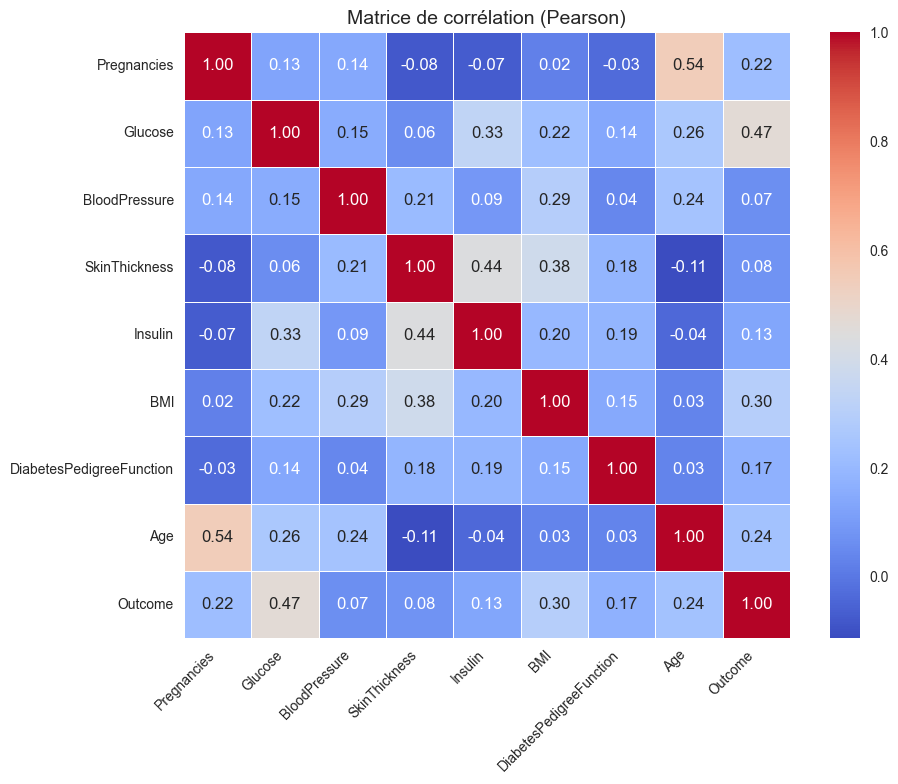

In [9]:
plt.figure(figsize=(10, 8))
corr = data.corr(method='pearson')
sns.heatmap(
    corr,
    annot=True,          # afficher les valeurs
    fmt=".2f",            # 2 chiffres après la virgule
    cmap="coolwarm",      # palette de couleurs
    linewidths=0.5,       # lignes entre les cellules
    square=True,          # carrés parfaits
    cbar=True             # afficher la barre de couleur
)
plt.title("Matrice de corrélation (Pearson)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
(data['Outcome'].value_counts())/data.shape[0]*100

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

**Intérpretation**: Dans cet ensemble de données, environ 65 % des tests sont négatifs au diabète, tandis que 35 % sont positifs, ce qui montre un léger déséquilibre entre les deux classes.

#### **4. Analayse des valeurs manquantes et les doublons**
1. **Définition**:
- Une valeur manquante, c’est une donnée absente dans le tableau, comme une case vide là où il devrait y avoir une valeur.
- Une ligne de données identique à une autre (erreur de frappe, d’une mauvaise saisie)
2. **Quand on détecte une valeurs manquantes ou un doublon dans un dataset, deux stratégies sont possibles**:
- Supprimer la ligne
- Remplacer les valeurs par la moyenne ou la médiane
3. **Décision**
- *Quand utiliser la SUPPRESSION des valeurs manquantes* ?\
=> Quand la ligne répétée ne t’apporte rien et beaucoup de nombre d'observation
- *Quand utiliser le REMPLACEMENT (moyenne/médiane) ?*\
=> Qand la ligne contient une petite variation et que tu veux garder l’information.\
`code:` - Remplace par moyenne: ``df.fillna(df.mean(numeric_only=True), inplace=True)`` ou \
        - Remplace par medéiane: `df.fillna(df.median(numeric_only=True), inplace=True)`

In [11]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               1
Insulin                     1
BMI                         1
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
data.duplicated().sum()
# data.drop_duplicates()

0

**Décision**: Nous allons supprimer les lignes contenant des valeurs manquantes, car le nombre d’observations est suffisamment élevé pour que cela n’impacte pas l’analyse.

In [13]:
data = data.dropna()
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### **III. Entraînement du modèle avec la bibliothèque PyCaret**
#### **Un flux de travail typique dans PyCaret se compose des 5 étapes suivantes, dans cet ordre :**
**``Setup`` ➡️ ``Compare Models`` ➡️ ``Analyze Model`` ➡️ ``Prediction`` ➡️ ``Save Model``**

#### **1. Initialisation**

In [14]:
in_set = setup(data = data, target='Outcome',session_id=123,normalize=True)
# data, target : variable cible, session_id:la clé qui bloque le hasard, normalize:normalise dans même échelle les valeur

,Description,Value
0,Session id,123
1,Target,Outcome
2,Target type,Binary
3,Original data shape,"(765, 9)"
4,Transformed data shape,"(765, 9)"
5,Transformed train set shape,"(535, 9)"
6,Transformed test set shape,"(230, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Intérpretation**:  Dans ce tableau, la bibliothèque PyCaret effectue automatiquement la séparation des données : environ 70 % sont utilisées pour l’entraînement et 30 % pour le test. À partir de ces données, elle réalise une évaluation du modèle et détecte également que la variable à prédire est binaire (1 ou 0), correspondant au test positif ou négatif du diabète.

#### **2. Comparaison entre différents modèles**

In [15]:
best_model = compare_models(include=['lr','ridge'])
# lr : Logistic Regression
# ridge : Ridge Classifier

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7640,0.8143,0.5573,0.6983,0.6160,0.4501,0.4584,1.1980
ridge,Ridge Classifier,0.7640,0.8164,0.5468,0.7028,0.6109,0.4471,0.4565,0.0440


**Intérprétation et décision**: 
> D'après ce tableau, l'algorithme Logistic Regression semble recommandé car il présente de bonnes performances sur presque tous les indicateurs. Cela suggère qu’il est globalement plus performant que les autres. Toutefois, la présence de plusieurs cellules colorées en jaune réparties sur différentes variables montre que la performance n’est pas clairement dominante, et qu’aucun modèle ne se démarque de manière nette sur tous les critères.  
>  
> Pour améliorer la précision, nous allons donc utiliser une méthode d’ensemble via la commande `ensemble_model`. Cette approche combine plusieurs modèles en faisant la moyenne de leurs prédictions, ce qui permet souvent d’obtenir un modèle plus robuste et plus performant.


#### **3. Création de modèle**
PyCaret propose trois types de méthodes d'ensemble pour améliorer les performances des modèles.
- *Bagging* :\
**Effet**:réduit l’overfitting et rend le modèle plus stable\
**Quand l’utiliser**: Dataset petit ou bruité, Modèle instable (ex : arbre de décision)\
**code**:``ensemble_model(best_model, method='Bagging')``
- *Boosting*:\
**Effet**:améliore fortement la précision\
**Quand l'Utiliser**: Données complexes, Quand la performance est encore faible\
**Code**: `ensemble_model(best_model, method='Boosting')`
- *Blending*:\
**Effet**:équilibre les forces des modèles.\
**Quand l'utiliser**:Plusieurs modèles performants, Besoin d’un gain rapide\
**Code**:`ensemble_model(best_model, method='Blending')`

In [23]:
ensemble = ensemble_model(best_model, method='Boosting')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7222,0.8211,0.5263,0.6250,0.5714,0.3682,0.3711
1,0.8519,0.8496,0.7368,0.8235,0.7778,0.6672,0.6695
2,0.7593,0.8992,0.4211,0.8000,0.5517,0.4081,0.4474
3,0.8889,0.9639,0.8421,0.8421,0.8421,0.7564,0.7564
4,0.7593,0.8602,0.4737,0.7500,0.5806,0.4236,0.4456
5,0.7547,0.7333,0.5000,0.6923,0.5806,0.4136,0.4246
6,0.7170,0.7413,0.4444,0.6154,0.5161,0.3234,0.3320
7,0.7925,0.8222,0.5000,0.8182,0.6207,0.4890,0.5171
8,0.7547,0.8476,0.4444,0.7273,0.5517,0.3961,0.4189


#### **4. Optimisation des hyperparamètres**

In [24]:
opt = tune_model(ensemble)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7593,0.7977,0.6316,0.6667,0.6486,0.4658,0.4661
1,0.8519,0.8361,0.7895,0.7895,0.7895,0.6752,0.6752
2,0.8704,0.8677,0.7368,0.8750,0.8000,0.7051,0.7108
3,0.8704,0.9609,0.8947,0.7727,0.8293,0.7257,0.7308
4,0.7407,0.7489,0.5789,0.6471,0.6111,0.4176,0.4190
5,0.6981,0.7206,0.5000,0.5625,0.5294,0.3083,0.3095
6,0.7358,0.7389,0.5000,0.6429,0.5625,0.3775,0.3836
7,0.7547,0.7587,0.5556,0.6667,0.6061,0.4301,0.4339
8,0.7736,0.7889,0.6111,0.6875,0.6471,0.4812,0.4830


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


#### **5. Evaluation de modèle**

In [25]:
evaluate_model(opt)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### **6. Analyse graphique des performances du modèle**

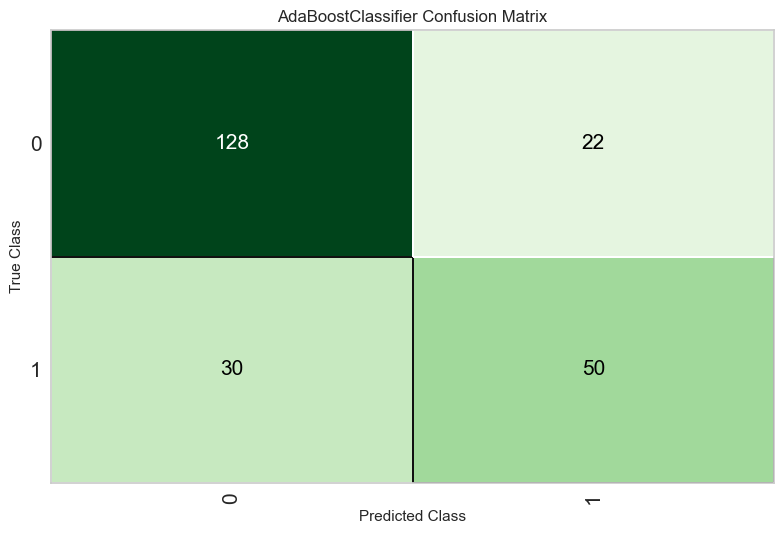

In [26]:
plot_model(opt, plot='confusion_matrix')
# plot_model(ensemble,plot='feature')

#### **7. Finalisation de l’entraînement du modèle**

In [28]:
finalize_model(opt)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Pregnancies', 'Glucose',
                                             'BloodPressure', 'SkinThickness',
                                             'Insulin', 'BMI',
                                             'DiabetesPedigreeFunction',
                                             'Age'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                (...
                 AdaBoostClassifier(algorithm='SAMME',
                                    estimator=LogisticRegression(C=1.0,
                                                                 class_weight=None,
                                                                 dual=False,
                                                                 fit_intercept=True,
                                                                 intercept_scaling=1,
                                                                 l1_ratio=None,
                                                                 max_iter=1000,
                                                                 multi_class='auto',
                                                                 n_jobs=None,
                                                                 penalty='l2',
                                                                 random_state=123,
                                                                 solver='lbfgs',
                                                                 tol=0.0001,
                                                                 verbose=0,
                                                                 warm_start=False),
                                    learning_rate=0.05, n_estimators=210,
                                    random_state=123))],
         verbose=False)

#### **8. Prédiction dans une nouvelle donnée**

In [31]:
new_data = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 12,
    "BloodPressure": 72,
    "SkinThickness": 25,
    "Insulin": 130,
    "BMI": 32.4,
    "DiabetesPedigreeFunction": 0.45,
    "Age": 29
}])
new_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,12,72,25,130,32.4,0.45,29


In [32]:
prediction = predict_model(ensemble,data=new_data)
prediction

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,prediction_label,prediction_score
0,2,12,72,25,130,32.400002,0.45,29,0,0.5989


#### **9. Sauvegarde de modèle**

In [33]:
save_model(opt,'../model/modele_classification')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Pregnancies', 'Glucose',
                                              'BloodPressure', 'SkinThickness',
                                              'Insulin', 'BMI',
                                              'DiabetesPedigreeFunction',
                                              'Age'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 (...
          